# 의료시설 접근성 — 2026-09-01 09:00 (오전 첨두) 대중교통 TravelTimeMatrix

r5py `TravelTimeMatrix`로, 건물 존재 100m 격자(`grid_100m_daegugyeongbuk_with_buildings`, 144,528개) 중심점에서
가장 가까운 의료시설까지의 대중교통 통행시간을 계산하고 4단계 단계구분도로 시각화한다.

## 파라미터

| 항목 | 값 |
|---|---|
| Origin | 건물 존재 100m 격자 중심점 (144,528개) |
| Destination | 의료시설(병원·의원·종합병원·보건소·보건지소·보건의료원·보건진료소), 대상 지역 20km 버퍼 내 (3,887개) |
| 출발일시 | 2026-09-01 09:00:00 (오전 첨두) |
| departure_time_window | 1시간 |
| transport_modes | TRANSIT, WALK |
| speed_walking | 4.5 km/h |
| max_time | 60분 |
| max_time_walking | 15분 |
| max_public_transport_rides | 5회 |

무거운 계산(`compute_ttm_nearest_facility.py`, 약 1.8시간 소요)은 별도 스크립트로 백그라운드 실행하며,
이 노트북은 그 결과(`data/accessibility_ttm_20260901_0900/nearest_facility_travel_time.csv`)를 불러와
격자 지오메트리와 결합해 지도화하는 역할만 한다.

**목적지 범위에 대한 설계 노트**: 의료시설을 대상 지역(17개 시군구) 안으로만 제한하면, 경계에 인접한 격자가
실제로는 더 가까운 인근 지역 병원을 이용할 수 있음에도 그 병원이 데이터에서 빠져 접근성이 실제보다
나쁘게 계산되는 왜곡이 생긴다. 이를 피하기 위해 대상 지역 경계에서 20km 버퍼를 두고 그 안의 의료시설을
모두 목적지로 포함했다 (버퍼를 넓혀도 추가되는 시설 수는 급격히 줄어들어 20km가 합리적인 지점 — 0km: 3,039개,
10km: 3,294개, 20km: 3,887개, 30km: 4,848개, 50km: 7,914개).

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

## 결과 로드 및 격자와 결합

In [2]:
RESULT_CSV = "data/accessibility_ttm_20260901_0900/nearest_facility_travel_time.csv"

ttm_result = pd.read_csv(RESULT_CSV)
print(f"계산된 격자: {len(ttm_result)}개 / 전체 144,528개")
print(f"60분 내 도달 불가: {ttm_result['nearest_facility_min'].isna().sum()}개")
ttm_result.head()

계산된 격자: 144528개 / 전체 144,528개
60분 내 도달 불가: 54032개


,id,nearest_facility_min,SPO_NO_CD
0,G0,2.0,씪留994639
1,G1,7.0,留덈쭏013652
2,G10,24.0,留덈쭏071739
3,G100,28.0,씪諛730115
4,G1000,40.0,留덈쭏399789


In [3]:
grid = gpd.read_file(
    "data/grid_100m_daegugyeongbuk_with_buildings/grid_100m_daegugyeongbuk_with_buildings.shp",
    encoding="cp949",
)
grid = grid.reset_index(drop=True)
grid["id"] = "G" + grid.index.astype(str)

grid_computed = grid.merge(ttm_result[["id", "nearest_facility_min"]], on="id", how="inner")
print(f"현재까지 계산 완료된 격자: {len(grid_computed)}개 / 전체 {len(grid)}개")

현재까지 계산 완료된 격자: 144528개 / 전체 144528개


## 4단계 단계구분도 (+ 60분 초과/도달불가)

요청한 4단계(0~15, 15~30, 30~45, 45~60분)에 더해, `max_time=60분` 제약으로 인해
60분 내 어떤 의료시설에도 도달하지 못하는 격자를 별도 회색 범주로 명시적으로 표시한다
(조용히 빈 칸으로 두면 실제로는 "도달 불가"인 지역이 "데이터 없음"과 구별되지 않기 때문).

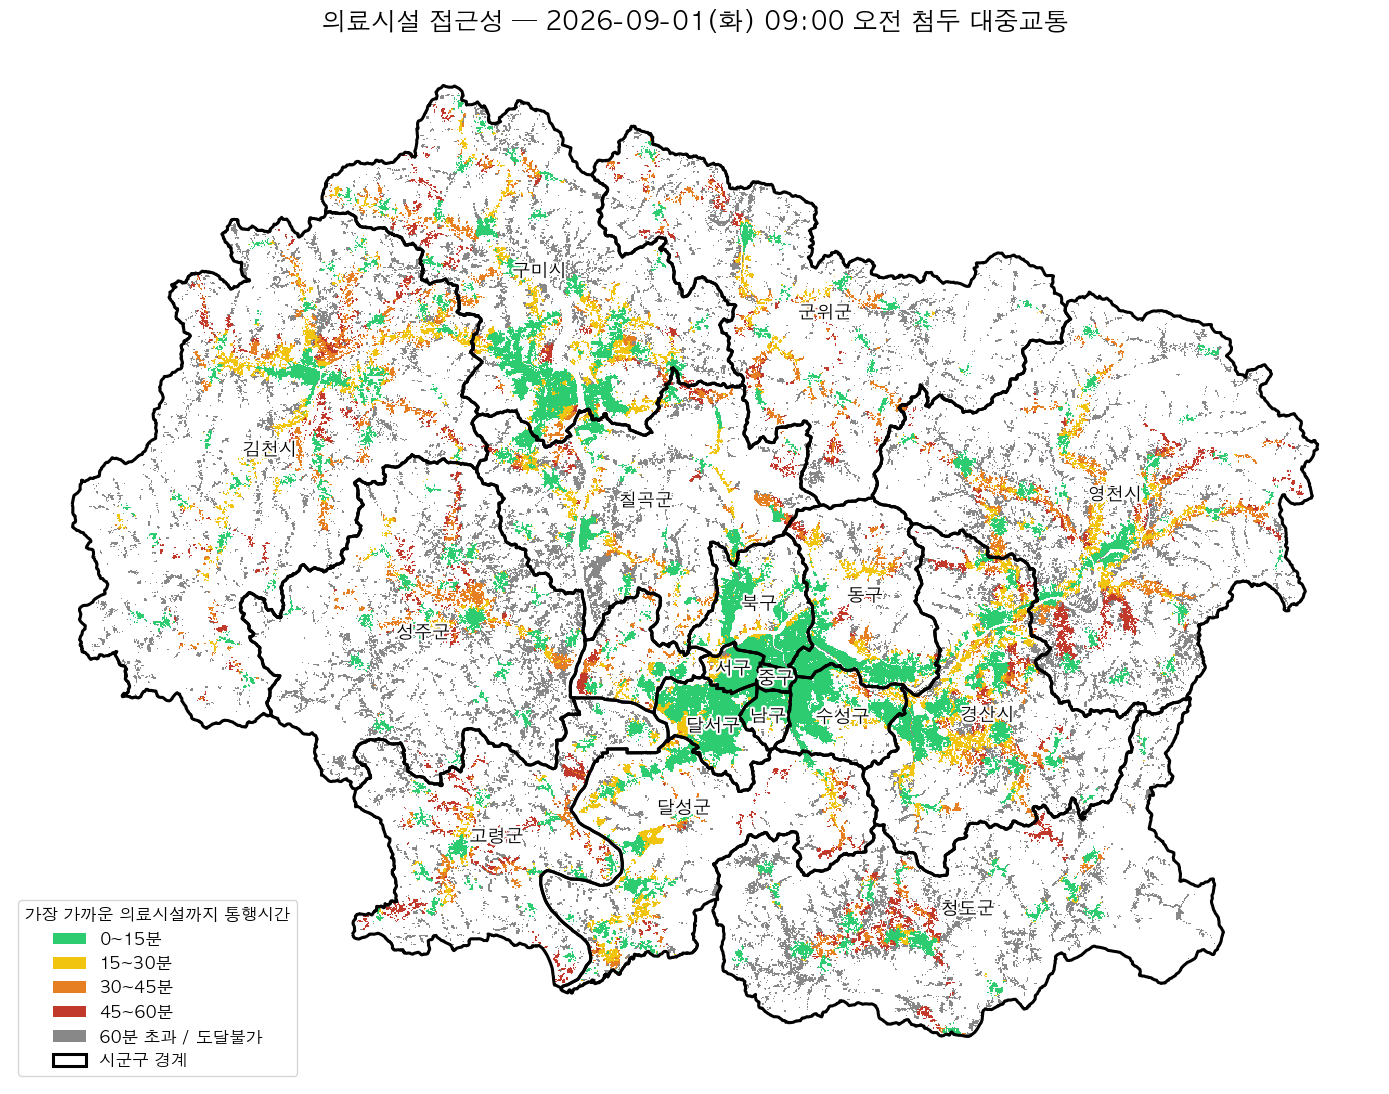

In [4]:
BINS = [0, 15, 30, 45, 60]
BIN_LABELS = ["0~15분", "15~30분", "30~45분", "45~60분"]
BIN_COLORS = ["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"]
UNREACHABLE_COLOR = "#888888"

grid_computed["time_class"] = pd.cut(
    grid_computed["nearest_facility_min"], bins=BINS, labels=BIN_LABELS, include_lowest=True
)

sigungu = gpd.read_file("data/BND_SIGUNGU_PG/BND_SIGUNGU_PG.shp", encoding="cp949")
target_codes = [
    "22010", "22020", "22030", "22040", "22050", "22060", "22070", "22510", "22520",
    "37050", "37030", "37070", "37100", "37560", "37570", "37580", "37590",
]
target_sigungu = sigungu[sigungu["SIGUNGU_CD"].isin(target_codes)].to_crs(grid.crs)

fig, ax = plt.subplots(figsize=(14, 14))

unreachable = grid_computed[grid_computed["nearest_facility_min"].isna()]
if len(unreachable) > 0:
    unreachable.plot(ax=ax, color=UNREACHABLE_COLOR, zorder=1)

for label, color in zip(BIN_LABELS, BIN_COLORS):
    sub = grid_computed[grid_computed["time_class"] == label]
    if len(sub) > 0:
        sub.plot(ax=ax, color=color, zorder=2)

target_sigungu.boundary.plot(ax=ax, color="black", linewidth=2.2, zorder=3)
for _, row in target_sigungu.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["SIGUNGU_NM"], xy=(c.x, c.y), ha="center", va="center",
        fontsize=13, fontweight="bold", color="black", zorder=4,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

legend_elements = [Patch(facecolor=c, label=l) for l, c in zip(BIN_LABELS, BIN_COLORS)]
legend_elements.append(Patch(facecolor=UNREACHABLE_COLOR, label="60분 초과 / 도달불가"))
legend_elements.append(Patch(facecolor="none", edgecolor="black", linewidth=2.2, label="시군구 경계"))
ax.legend(handles=legend_elements, loc="lower left", fontsize=12, title="가장 가까운 의료시설까지 통행시간",
          title_fontsize=12)

ax.set_title("의료시설 접근성 — 2026-09-01(화) 09:00 오전 첨두 대중교통", fontsize=18, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("data/accessibility_ttm_20260901_0900/accessibility_map_20260901_0900.png", dpi=200)
plt.show()

## 결과 저장

In [5]:
import os

out_dir = "data/accessibility_ttm_20260901_0900"
os.makedirs(out_dir, exist_ok=True)
grid_out = grid_computed.drop(columns=["id"]).rename(columns={"nearest_facility_min": "TT_MIN"})
grid_out.to_file(f"{out_dir}/grid_nearest_facility_20260901_0900.shp", encoding="cp949")
print("저장 완료:", f"{out_dir}/grid_nearest_facility_20260901_0900.shp")

grid_computed["nearest_facility_min"].describe()

저장 완료: data/accessibility_ttm_20260901_0900/grid_nearest_facility_20260901_0900.shp


count    90496.000000
mean        21.601574
std         16.825431
min          0.000000
25%          7.000000
50%         15.000000
75%         35.000000
max         59.000000
Name: nearest_facility_min, dtype: float64